<a href="https://colab.research.google.com/github/Nubiga-lima/kyc-risk-model/blob/main/notebooks/03_model_development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## KYC Risk Model — Model Development

In [34]:
!pip install shap --quiet

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shap

### 1. Load Engineered Dataset

In [35]:
df = pd.read_csv("data/processed/kyc_features.csv")
print("Engineered dataset loaded. Shape:", df.shape)
df.head()

Engineered dataset loaded. Shape: (5000, 18)


,customer_id,age,monthly_txn_count,monthly_txn_volume,unusual_txn_flag,product_risk_score,pep_flag,adverse_media_flag,high_risk_jurisdiction,risk_score,risk_class,country_risk_Low,country_risk_Medium,txn_intensity,high_volume_flag,pep_high_risk_interaction,media_pep_combo,behavioural_risk_score
0,1,0.931467,0.644872,1.792729,0,1,0,0,0,0.027894,Low,1.0,0.0,1.169628,0,0,0,0.0
1,2,-0.984769,1.091243,0.800086,0,1,0,0,0,0.043825,Low,1.0,0.0,0.271993,0,0,0,0.0
2,3,1.397579,-1.140612,-0.657155,0,1,0,0,0,0.052781,Low,1.0,0.0,-0.427014,0,0,0,0.0
3,4,-0.674028,-1.363798,1.374910,0,1,0,0,0,0.224441,Medium,1.0,0.0,2.140519,0,0,0,0.0
4,5,-0.518658,-0.024684,0.030972,0,2,0,0,0,0.000000,Low,0.0,1.0,-0.030005,0,0,0,0.0


### 2. Define Features and Target

In [36]:
feature_cols = [
    "age",
    "monthly_txn_count",
    "monthly_txn_volume",
    "product_risk_score",
    "unusual_txn_flag",
    "pep_flag",
    "adverse_media_flag",
    "high_risk_jurisdiction",
    "country_risk_Low",
    "country_risk_Medium",
    "txn_intensity",
    "high_volume_flag",
    "pep_high_risk_interaction",
    "media_pep_combo",
    "behavioural_risk_score"
]

X = df[feature_cols]
y = df["risk_class"]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())
print("\nNote: dataset is heavily imbalanced (Low >> Medium >> High).")
print("Class weighting applied in both models to mitigate majority-class bias.")

Feature matrix shape: (5000, 15)
Target distribution:
 risk_class
Low       4178
Medium     792
High        30
Name: count, dtype: int64

Note: dataset is heavily imbalanced (Low >> Medium >> High).
Class weighting applied in both models to mitigate majority-class bias.


### 3. Train/Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3500, 15)
Test shape: (1500, 15)


### 4. Baseline Model — Logistic Regression

=== Logistic Regression – Classification Report ===
              precision    recall  f1-score   support

        High       0.11      0.78      0.19         9
         Low       0.90      0.97      0.93      1253
      Medium       0.62      0.24      0.34       238

    accuracy                           0.85      1500
   macro avg       0.54      0.66      0.49      1500
weighted avg       0.85      0.85      0.83      1500



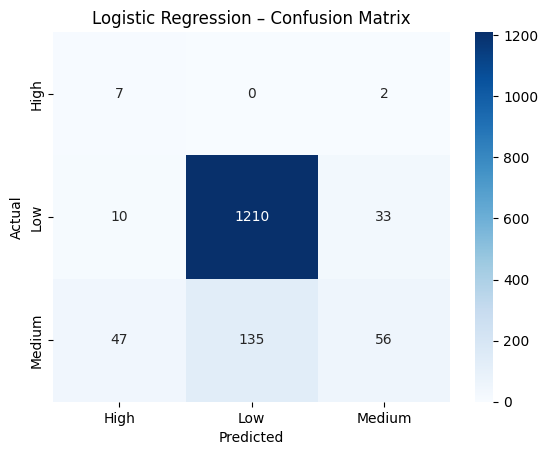

In [38]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("=== Logistic Regression – Classification Report ===")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=log_reg.classes_)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.title("Logistic Regression – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5. Challenger Model — Random Forest

=== Random Forest – Classification Report ===
              precision    recall  f1-score   support

        High       0.06      0.11      0.08         9
         Low       0.90      0.97      0.93      1253
      Medium       0.64      0.37      0.47       238

    accuracy                           0.87      1500
   macro avg       0.54      0.48      0.49      1500
weighted avg       0.85      0.87      0.85      1500



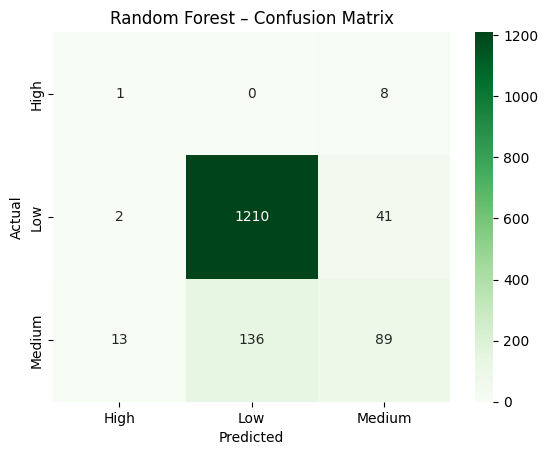

In [39]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest – Classification Report ===")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 6. Feature Importance (Random Forest)

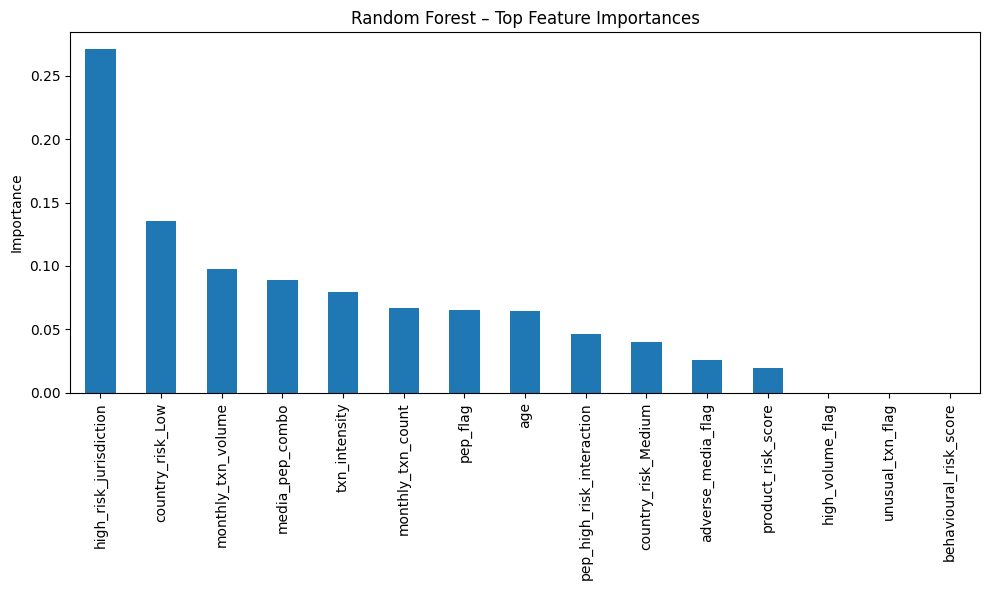

In [40]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind="bar")
plt.title("Random Forest – Top Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

### 7. Explainability with SHAP (Random Forest)

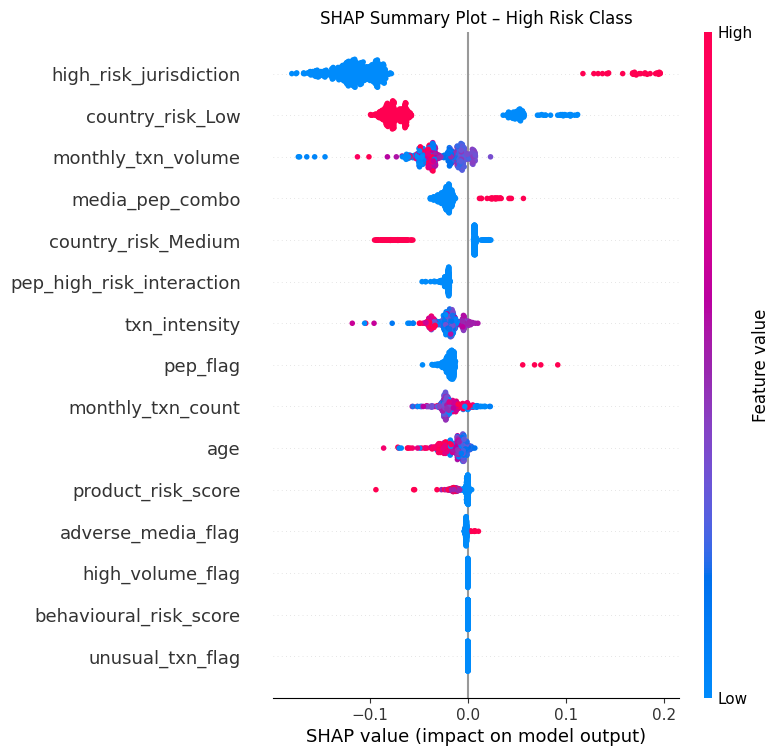

In [41]:
X_sample = X_test.sample(500, random_state=42)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

class_index = list(rf.classes_).index("High")

# Handle both old (list of arrays) and new (single 3D array) SHAP APIs
if isinstance(shap_values, list):
    shap_vals_for_class = shap_values[class_index]
else:
    shap_vals_for_class = shap_values[:, :, class_index]

shap.summary_plot(
    shap_vals_for_class,
    X_sample,
    feature_names=feature_cols,
    show=False
)
plt.title("SHAP Summary Plot – High Risk Class")
plt.show()

### 8. Model Comparison Summary

In [42]:
print("Model development complete.")
print("Baseline (Logistic Regression) and challenger (Random Forest) models trained,")
print("with class-weighting applied to address label imbalance.")
print("Metrics and SHAP outputs above will be documented in model_documentation.md")
print("and model_validation_report.md.")

Model development complete.
Baseline (Logistic Regression) and challenger (Random Forest) models trained,
with class-weighting applied to address label imbalance.
Metrics and SHAP outputs above will be documented in model_documentation.md
and model_validation_report.md.
